# RNN - IMDB Movie Review Sentiment Analysis
## Using Keras IMDB Dataset
This notebook demonstrates a complete RNN/LSTM pipeline:
- Data Loading from Keras built-in IMDB dataset
- Text Preprocessing & Sequence Padding
- EDA on review lengths and word distributions
- LSTM Model Building, Training, and Evaluation
- Saving the model + tokenizer for deployment

## Step 1: Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Dense, Dropout, Bidirectional, SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print('TensorFlow version:', tf.__version__)
print('All libraries loaded successfully!')

TensorFlow version: 2.21.0
All libraries loaded successfully!


## Step 2: Load the Dataset

In [2]:
# IMDB dataset: 50,000 movie reviews labeled as positive (1) or negative (0)
# vocab_size: keep only the top 10,000 most frequent words
VOCAB_SIZE  = 10000
MAX_LEN     = 200    # Pad/truncate all reviews to 200 words

print('Loading IMDB dataset from Keras...')
(X_train_raw, y_train), (X_test_raw, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print(f'Training samples : {len(X_train_raw)}')
print(f'Test samples     : {len(X_test_raw)}')
print(f'Label values     : {np.unique(y_train)}  (0=Negative, 1=Positive)')

# Load the word index for decoding reviews back to text
word_index = imdb.get_word_index()
# Reverse: integer → word
index_word = {v+3: k for k, v in word_index.items()}
index_word.update({0: '<PAD>', 1: '<START>', 2: '<UNK>', 3: '<UNUSED>'})

def decode_review(encoded):
    """Convert a list of integers back to a readable review string."""
    return ' '.join(index_word.get(i, '?') for i in encoded)

# Preview a sample review
print('\n--- Sample Review (first training item) ---')
print(decode_review(X_train_raw[0])[:500], '...')
print(f'\nLabel: {"Positive" if y_train[0] == 1 else "Negative"}')

Loading IMDB dataset from Keras...
Training samples : 25000
Test samples     : 25000
Label values     : [0 1]  (0=Negative, 1=Positive)

--- Sample Review (first training item) ---
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would re ...

Label: Positive


## Step 3: Data Preprocessing

In [3]:
# Reviews have variable length; LSTM needs fixed-length inputs.
# pad_sequences: shorter reviews are zero-padded, longer ones are truncated.
# truncating='post' and padding='post' ensures consistent handling.

X_train = pad_sequences(X_train_raw, maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(X_test_raw,  maxlen=MAX_LEN, padding='post', truncating='post')

print('After padding:')
print(f'  X_train shape: {X_train.shape}  (samples × sequence_length)')
print(f'  X_test  shape: {X_test.shape}')
print(f'  y_train shape: {y_train.shape}')
print(f'  y_test  shape: {y_test.shape}')

# Save the tokenizer metadata (word_index) for the app
with open('../models/word_index.pkl', 'wb') as f:
    pickle.dump(word_index, f)
print('\nWord index saved for deployment.')

After padding:
  X_train shape: (25000, 200)  (samples × sequence_length)
  X_test  shape: (25000, 200)
  y_train shape: (25000,)
  y_test  shape: (25000,)

Word index saved for deployment.


## Step 4: Exploratory Data Analysis (EDA)

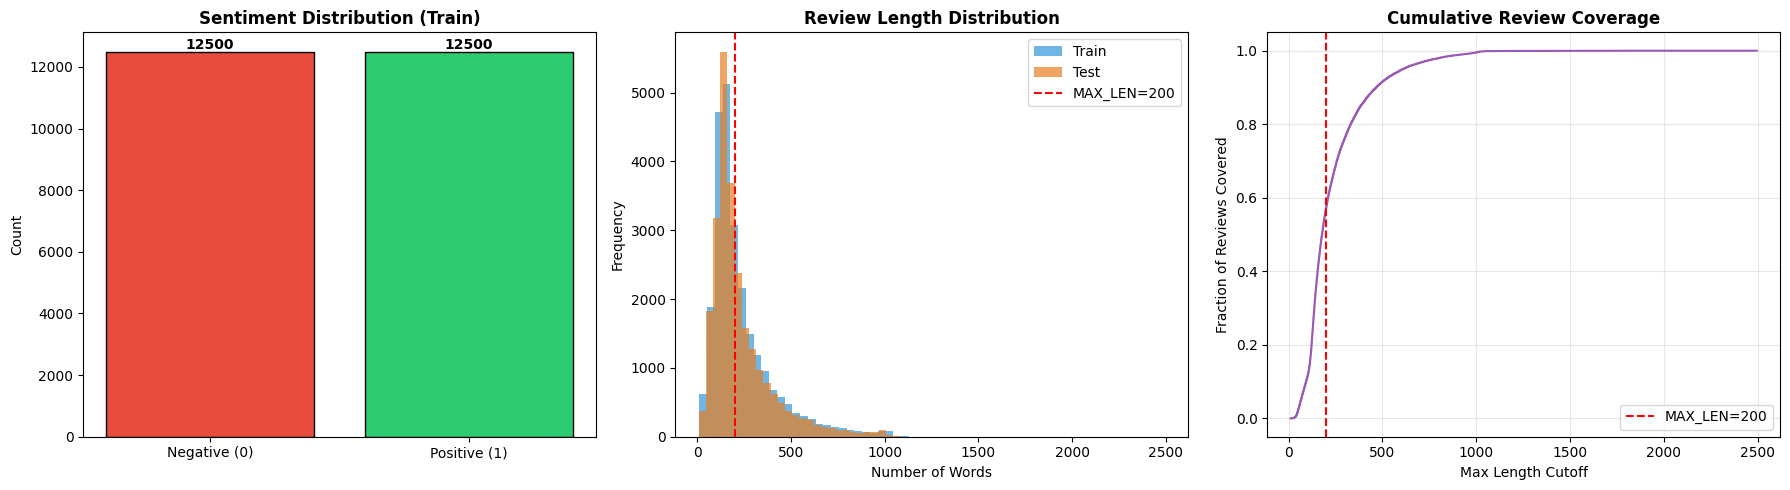

Review length stats (train):
  Min: 11 | Max: 2494 | Mean: 239 | Median: 178
  Reviews fully covered at MAX_LEN=200: 57.3%


In [5]:
# Compute original review lengths before padding
train_lengths = [len(r) for r in X_train_raw]
test_lengths  = [len(r) for r in X_test_raw]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Label distribution
unique, counts = np.unique(y_train, return_counts=True)
axes[0].bar(['Negative (0)', 'Positive (1)'], counts,
            color=['#E74C3C', '#2ECC71'], edgecolor='black')
axes[0].set_title('Sentiment Distribution (Train)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Plot 2: Review length distribution
axes[1].hist(train_lengths, bins=60, color='#3498DB', alpha=0.7, label='Train')
axes[1].hist(test_lengths,  bins=60, color='#E67E22', alpha=0.7, label='Test')
axes[1].axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
axes[1].set_title('Review Length Distribution', fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Plot 3: Cumulative coverage by max_len
sorted_len = np.sort(train_lengths)
cumulative = np.arange(1, len(sorted_len)+1) / len(sorted_len)
axes[2].plot(sorted_len, cumulative, color='#9B59B6')
axes[2].axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
axes[2].set_title('Cumulative Review Coverage', fontweight='bold')
axes[2].set_xlabel('Max Length Cutoff')
axes[2].set_ylabel('Fraction of Reviews Covered')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/eda_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Review length stats (train):')
print(f'  Min: {min(train_lengths)} | Max: {max(train_lengths)} | Mean: {np.mean(train_lengths):.0f} | Median: {np.median(train_lengths):.0f}')
cov = np.mean(np.array(train_lengths) <= MAX_LEN)
print(f'  Reviews fully covered at MAX_LEN={MAX_LEN}: {cov:.1%}')

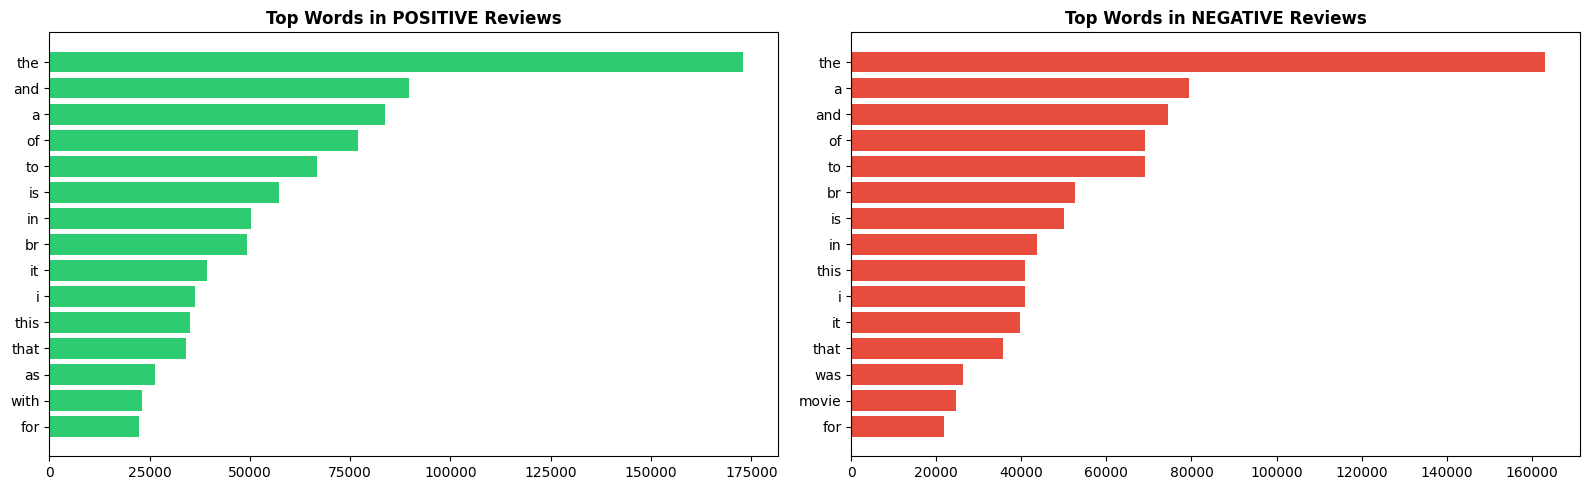

In [6]:
# --- Top Words in Positive vs Negative Reviews ---
from collections import Counter

pos_words = [w for review, label in zip(X_train_raw, y_train)
             if label == 1 for w in review if w >= 3]
neg_words = [w for review, label in zip(X_train_raw, y_train)
             if label == 0 for w in review if w >= 3]

top_pos = Counter(pos_words).most_common(15)
top_neg = Counter(neg_words).most_common(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

words_p, counts_p = zip(*top_pos)
ax1.barh([index_word.get(w, '?') for w in words_p], counts_p, color='#2ECC71')
ax1.set_title('Top Words in POSITIVE Reviews', fontweight='bold')
ax1.invert_yaxis()

words_n, counts_n = zip(*top_neg)
ax2.barh([index_word.get(w, '?') for w in words_n], counts_n, color='#E74C3C')
ax2.set_title('Top Words in NEGATIVE Reviews', fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('../data/eda_top_words.png', dpi=100, bbox_inches='tight')
plt.show()

## Step 5: Feature Engineering

Review length statistics by sentiment:
            count   mean    std   min    25%    50%    75%     max
label                                                             
Negative  12500.0  235.9  169.5  11.0  131.0  179.0  284.0  1571.0
Positive  12500.0  241.6  183.2  13.0  128.0  178.0  297.0  2494.0


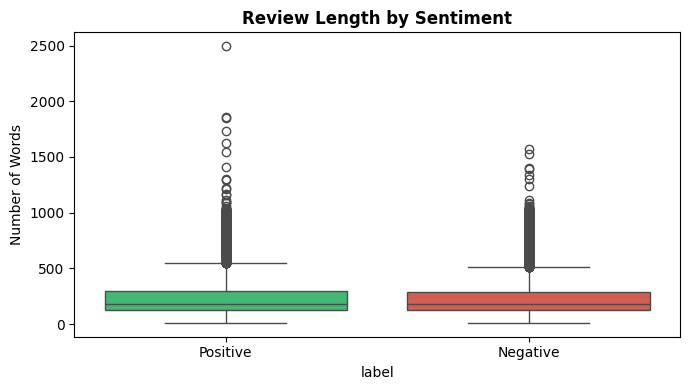

In [7]:
# Feature engineering for text/RNN involves:
# 1. Vocabulary clipping (already done via VOCAB_SIZE)
# 2. Sequence padding (done above)
# 3. Embedding layer (learned word vectors; handled inside the model)

# We also derive a quick length feature for EDA insight
df_eda = pd.DataFrame({
    'length': train_lengths,
    'label': ['Positive' if l == 1 else 'Negative' for l in y_train]
})

print('Review length statistics by sentiment:')
print(df_eda.groupby('label')['length'].describe().round(1))

# Boxplot: Do positive/negative reviews differ in length?
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_eda, x='label', y='length',
            palette={'Positive': '#2ECC71', 'Negative': '#E74C3C'})
plt.title('Review Length by Sentiment', fontweight='bold')
plt.ylabel('Number of Words')
plt.tight_layout()
plt.savefig('../data/eda_length_by_sentiment.png', dpi=100, bbox_inches='tight')
plt.show()

## Step 6: Train-Test Split

In [8]:
# IMDB from Keras is pre-split: 25,000 train + 25,000 test
# Confirming split statistics
print('Dataset split summary:')
print(f'  Training   : {len(X_train)} samples | Pos={sum(y_train)} | Neg={sum(y_train==0)}')
print(f'  Test       : {len(X_test)} samples  | Pos={sum(y_test)}  | Neg={sum(y_test==0)}')
print(f'  Train ratio: {len(X_train)/(len(X_train)+len(X_test)):.0%} / {len(X_test)/(len(X_train)+len(X_test)):.0%}')

Dataset split summary:
  Training   : 25000 samples | Pos=12500 | Neg=12500
  Test       : 25000 samples  | Pos=12500  | Neg=12500
  Train ratio: 50% / 50%


## Step 7: Build & Train the LSTM Model

In [9]:
EMBED_DIM = 128   # Size of word embedding vectors

def build_lstm(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, max_len=MAX_LEN):
    """
    Build a Bidirectional LSTM model for binary sentiment classification.
    Architecture:
      Embedding → SpatialDropout → BiLSTM → Dropout → Dense
    """
    model = Sequential([
        # Embedding: Learn dense vector representations for each word
        # Input: integer sequences; Output: (batch, max_len, embed_dim)
        Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=max_len),

        # SpatialDropout: Drop entire embedding dimensions (better for NLP than regular Dropout)
        SpatialDropout1D(0.2),

        # Bidirectional LSTM: Reads sequence both forward and backward
        # Captures context from both past and future words
        Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),

        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')   # Binary: 0=Negative, 1=Positive
    ])
    return model

model = build_lstm()
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

print('\nTraining complete!')

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 427s 2s/step - accuracy: 0.7020 - loss: 0.5646 - val_accuracy: 0.8212 - val_loss: 0.4093 - learning_rate: 0.0010
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 449s 2s/step - accuracy: 0.8356 - loss: 0.3923 - val_accuracy: 0.8402 - val_loss: 0.3925 - learning_rate: 0.0010
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 472s 2s/step - accuracy: 0.8661 - loss: 0.3366 - val_accuracy: 0.8088 - val_loss: 0.4290 - learning_rate: 0.0010
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8879 - loss: 0.2888
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
196/196 ━━━━━━━━━━━━━━━━━━━━ 497s 3s/step - accuracy: 0.8870 - loss: 0.2966 - val_accuracy: 0.8295 - val_loss: 0.4023 - learning_rate: 0.0010
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 496s 3s/step - accuracy: 0.9110 - loss: 0.2430 - val_accuracy: 0.8328 - val_loss: 0.4132 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2

## Step 8: Predictions

In [11]:
# Predict probabilities on the test set
y_pred_prob = model.predict(X_test, verbose=0).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

print('Sample predictions (first 10 test reviews):')
for i in range(10):
    actual    = 'Positive' if y_test[i]  == 1 else 'Negative'
    predicted = 'Positive' if y_pred[i]  == 1 else 'Negative'
    conf      = y_pred_prob[i] if y_pred[i] == 1 else 1 - y_pred_prob[i]
    status    = '✓' if y_test[i] == y_pred[i] else '✗'
    print(f'  {status} Actual: {actual:9s} | Predicted: {predicted:9s} | Confidence: {conf:.2%}')

Sample predictions (first 10 test reviews):
  ✓ Actual: Negative  | Predicted: Negative  | Confidence: 97.14%
  ✓ Actual: Positive  | Predicted: Positive  | Confidence: 90.91%
  ✓ Actual: Positive  | Predicted: Positive  | Confidence: 89.82%
  ✓ Actual: Negative  | Predicted: Negative  | Confidence: 95.71%
  ✓ Actual: Positive  | Predicted: Positive  | Confidence: 92.02%
  ✗ Actual: Positive  | Predicted: Negative  | Confidence: 81.67%
  ✓ Actual: Positive  | Predicted: Positive  | Confidence: 71.10%
  ✓ Actual: Negative  | Predicted: Negative  | Confidence: 93.43%
  ✗ Actual: Negative  | Predicted: Positive  | Confidence: 92.77%
  ✗ Actual: Positive  | Predicted: Negative  | Confidence: 90.12%


## Step 9: Model Evaluation Metrics

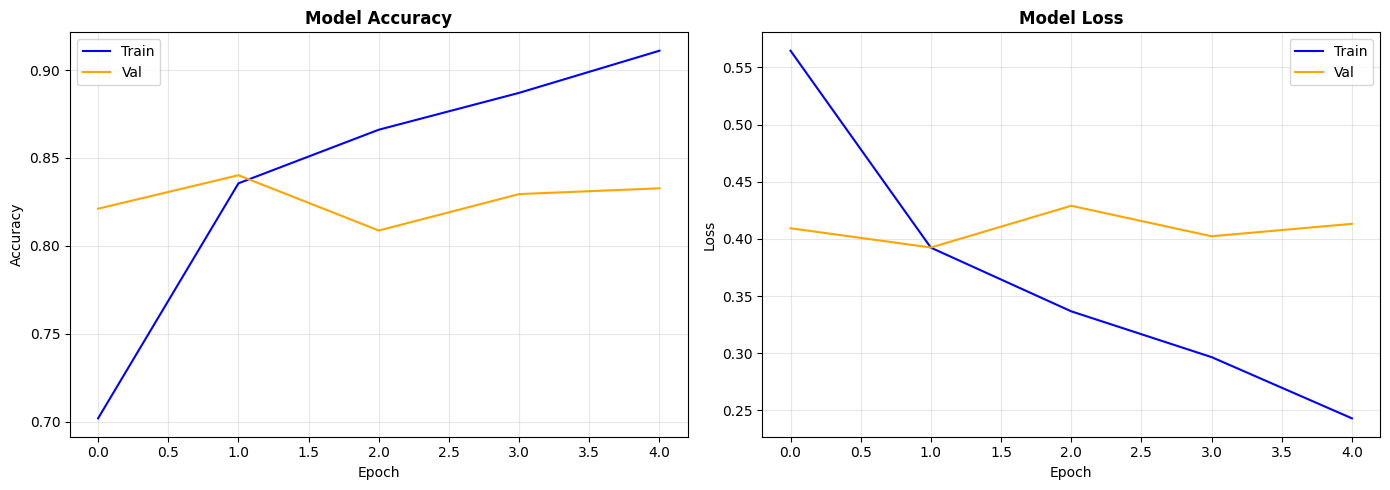

In [12]:
# --- Training History ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train', color='blue')
ax1.plot(history.history['val_accuracy'], label='Val',   color='orange')
ax1.set_title('Model Accuracy', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'],     label='Train', color='blue')
ax2.plot(history.history['val_loss'], label='Val',   color='orange')
ax2.set_title('Model Loss', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/training_history.png', dpi=100, bbox_inches='tight')
plt.show()

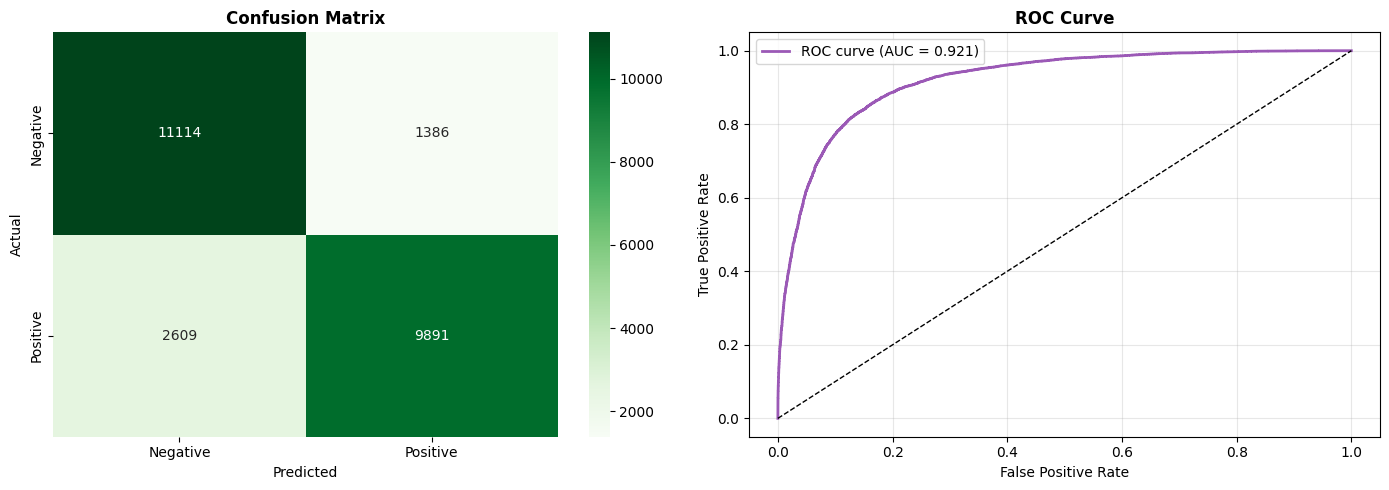

Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.89      0.85     12500
    Positive       0.88      0.79      0.83     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000

Accuracy : 0.8402
ROC-AUC  : 0.9209


In [13]:
# --- Confusion Matrix + ROC Curve ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax1,
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
ax1.set_title('Confusion Matrix', fontweight='bold')
ax1.set_ylabel('Actual'); ax1.set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)
ax2.plot(fpr, tpr, color='#9B59B6', lw=2, label=f'ROC curve (AUC = {auc:.3f})')
ax2.plot([0,1], [0,1], 'k--', lw=1)
ax2.set_title('ROC Curve', fontweight='bold')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/confusion_roc.png', dpi=100, bbox_inches='tight')
plt.show()

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Negative','Positive']))
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC  : {auc:.4f}')

## Step 10: Save the Model

In [14]:
# Save the trained LSTM model
model.save('../models/rnn_sentiment.keras')
print('Model saved → ../models/rnn_sentiment.keras')

# Save metadata for the app
meta = {
    'vocab_size': VOCAB_SIZE,
    'max_len': MAX_LEN,
    'embed_dim': EMBED_DIM,
    'final_val_accuracy': float(max(history.history['val_accuracy'])),
    'final_roc_auc': float(auc),
    'epochs_trained': len(history.history['accuracy'])
}
with open('../models/rnn_metadata.json', 'w') as f:
    json.dump(meta, f)

print('Metadata saved → ../models/rnn_metadata.json')
print(f"Best Val Accuracy : {meta['final_val_accuracy']:.4f}")
print(f"ROC-AUC           : {meta['final_roc_auc']:.4f}")

Model saved → ../models/rnn_sentiment.keras
Metadata saved → ../models/rnn_metadata.json
Best Val Accuracy : 0.8402
ROC-AUC           : 0.9209
